# Notebook 6: Pre-procesamiento Diferencial de EEG y EMG

## 6.1 Introducción y Objetivos

El análisis de señales bioeléctricas requiere una adaptación metodológica basada en la fisiología del sistema que estamos estudiando (por ejemplo: sistema musculoesquelético o sistema nervioso). Aunque el Electroencefalograma (EEG) y el Electromiograma (EMG) comparten principios de transducción eléctrica superficial, sus características espectrales y temporales difieren significativamente (Merletti & Hermens, 2000; Nunez & Srinivasan, 2006).

**Objetivo Central:** Comprender la fundamentación fisiológica que dicta por qué el EEG y el EMG requieren secuencias de pre-procesamiento distintos para extraer información válida.

Este análisis sigue la estructura comparativa de las siguientes etapas críticas:
*   **Adquisición:** Ubicación de electrodos y escalas de amplitud.
*  **Frecuencia de Muestreo:** Requerimientos temporales, como conocer las frecuencias a analizar.
*  **Filtrado Paso Banda:** Selección de bandas fisiológicas.
*  **Análisis en distintos dominios:** Tiempo o frecuencia.
*  **Métricas Típicas:** Ejercicios de potencia y espectrogramas.
*  **Interpretación:** Síntesis final.

## 6.2 Adquisición de las señales

Para iniciar el análisis comparativo, es fundamental establecer primero los puntos de encuentro. Tanto el EEG como el EMG son **registros extracelulares no invasivos**. Esta característica es crítica tanto para el diagnóstico clínico como para la investigación básica, ya que permite obtener datos de alta resolución temporal sobre la actividad fisiológica sin comprometer la integridad del tejido.

Físicamente, ambas señales comparten una naturaleza compuesta:
1.  **Suma de Potenciales:** Lo que registramos no es la actividad de una sola célula, sino la suma ponderada de campos eléctricos generados por miles de unidades activas simultáneamente.
2.  **El "Problema Inverso":** Debido a esta superposición, resulta extremadamente difícil separar la contribución individual de una sola neurona o una sola fibra muscular a partir del registro de superficie.

Sin embargo, la adquisición de la señal bioeléctrica no es un proceso pasivo; está condicionada por las propiedades físicas del **conductor de volumen** (los tejidos biológicos que separan la fuente del electrodo). Aquí es donde las diferencias anatómicas dictan la calidad y magnitud de la señal.

### El Conductor de Volumen y la Atenuación


* **EEG (Cuero cabelludo):** Según explican **Nunez y Srinivasan (2006)**, la señal registrada en el cuero cabelludo es el resultado de la sumación espacial de potenciales postsinápticos generados por grandes poblaciones de neuronas piramidales. El gran obstáculo aquí es el cráneo. El hueso actúa como un filtro espacial paso bajo y un aislante dieléctrico de alta impedancia, lo que atenúa la señal original significativamente y provoca un "desenfoque" (*smearing*) espacial. Como resultado, las amplitudes típicas son extremadamente bajas, oscilando en el rango de **10 a 100 $\mu V$**.

* **EMG (Piel sobre músculo):** Por el contrario, **Merletti y Hermens (2000)** describen la señal electromiográfica de superficie como la superposición interferencial de los Potenciales de Acción de Unidad Motora (MUAP). Al situar los electrodos directamente sobre el vientre muscular, la impedancia del tejido interpuesto (piel y grasa subcutánea) es mucho menor comparada con la del cráneo. Esto preserva la energía de la señal, resultando en amplitudes robustas que alcanzan fácilmente el rango de los **milivoltios (0.5 – 5 mV)**.

### Amplificación: dos filosofías para dos señales

Toda señal electrofisiológica necesita pasar por un paso de amplificación en el instrumento antes de ser digitalizada. Sin embargo, la estrategia de amplificación difiere radicalmente entre un equipo de EEG y uno de EMG, y la razón es precisamente la diferencia de escala que acabamos de describir.

**Emotiv EPOC X (EEG — 14 canales)**

El EPOC X emplea una arquitectura de amplificación integrada: el amplificador diferencial y el convertidor analógico-digital (ADC) residen en el mismo circuito integrado. El sistema utiliza un ADC de 16 bits que muestrea internamente a 2048 Hz y luego submuestrea digitalmente a 128 o 256 SPS (configurable por el usuario). De esos 16 bits, los 2 bits inferiores se descartan como piso de ruido instrumental, dejando una resolución efectiva de 14 bits con 0.51 µV por bit mínimo (LSB). 

¿Por qué esta resolución es necesaria? Recordemos que la señal de EEG oscila entre 10 y 100 µV. Si la resolución fuera de, digamos, 10 µV por bit, toda la dinámica del EEG quedaría comprimida en apenas 10 niveles digitales — insuficiente para distinguir estados cognitivos. Con 0.51 µV/LSB, el EPOC X puede resolver ~200 niveles dentro de una oscilación alfa típica de 100 µV pico a pico.

El rango dinámico del equipo es de 8400 µV pico a pico. El ancho de banda se limita a 0.2–45 Hz mediante filtros digitales (Sinc de 5° orden), con filtros notch a 50 y 60 Hz para eliminar interferencia de la red eléctrica. Además, el sistema utiliza un esquema de referencia CMS/DRL (Common Mode Sense / Driven Right Leg) que rechaza activamente el ruido común a todos los canales.

En resumen, la amplificación del EPOC X es "silenciosa" y digital: la señal se amplifica y digitaliza en un solo paso, priorizando la resolución sub-microvoltio necesaria para detectar actividad cortical a través del cráneo.

**Backyard Brains Muscle SpikerBox (EMG — 1-2 canales)**

El SpikerBox adopta un enfoque completamente distinto: amplificación analógica multietapa con componentes discretos (amplificadores operacionales). El circuito consta de dos etapas principales de amplificación, con una ganancia total de aproximadamente 1000×, y un filtro paso banda analógico de 300–1200 Hz.

¿Por qué funciona un enfoque tan diferente? La señal EMG ya llega en el rango de 0.5–5 mV (500–5000 µV), es decir, entre 50 y 100 veces más grande que el EEG. No se necesita la resolución sub-microvoltio; lo que se necesita es amplificar la señal lo suficiente para que sea audible (el SpikerBox incluye una bocina) y legible por un ADC más sencillo (10 bits en Arduino, o el codec de audio del smartphone a ~16 bits).

Un detalle práctico importante: cada canal del SpikerBox tiene una perilla de ganancia individual que permite ajustar la amplificación según el músculo que se está registrando. Un músculo grande como el bíceps produce señales más fuertes que un músculo pequeño del antebrazo, por lo que la ganancia necesita adaptarse. Este ajuste manual no sería práctico para un EEG de 14 canales, donde la ganancia debe ser uniforme y extremadamente precisa.

**¿Por qué esta diferencia importa para el pre-procesamiento?**

La consecuencia directa es que:

- En **EEG**, la señal ya llega digitalizada con alta fidelidad pero es extremadamente pequeña. Cualquier artefacto (movimiento muscular, parpadeo, ruido eléctrico) puede tener una amplitud comparable o mayor que la señal cerebral de interés. Por eso el filtrado digital posterior es crítico.

- En **EMG**, la señal es robusta y la amplificación analógica ya incorpora un primer filtrado (paso banda hardware). El reto es diferente: extraer la envolvente de activación de una señal que es inherentemente estocástica y ruidosa.




In [1]:
import pandas as pd

In [2]:
amp_data = {
    'Parámetro': ['Señal de entrada', 'Tipo de amplificación', 'Ganancia', 
                  'Resolución ADC', 'Ancho de banda', 'Canales', 'Ajuste de ganancia'],
    'EPOC X (EEG)': ['10–100 µV', 'Integrada (amp+ADC en chip)', '~12,800× implícita', 
                     '14 bits (0.51 µV/LSB)', '0.2–45 Hz digital', '14', 'Fija (calibrada)'],
    'SpikerBox (EMG)': ['0.5–5 mV', 'Analógica multietapa (op-amps)', '~1000× analógica', 
                        '10 bits (Arduino) o ~16 bits (audio)', '300–1200 Hz analógico', '1–2', 'Perilla manual']
}
pd.DataFrame(amp_data).set_index('Parámetro')

,EPOC X (EEG),SpikerBox (EMG)
Parámetro,,
Señal de entrada,10–100 µV,0.5–5 mV
Tipo de amplificación,Integrada (amp+ADC en chip),Analógica multietapa (op-amps)
Ganancia,"~12,800× implícita",~1000× analógica
Resolución ADC,14 bits (0.51 µV/LSB),10 bits (Arduino) o ~16 bits (audio)
Ancho de banda,0.2–45 Hz digital,300–1200 Hz analógico
Canales,14,1–2
Ajuste de ganancia,Fija (calibrada),Perilla manual



### El Rol del Amplificador Diferencial

Debido a estas diferencias de magnitud, la etapa de amplificación en el hardware de adquisición debe comportarse de manera distinta:

1.  **Ganancia (Gain):** Dado que el EEG es una señal de microvoltios, requiere una ganancia mucho mayor (típicamente entre 10,000 y 50,000 veces) para ser legible. El EMG, al estar en milivoltios, requiere una ganancia menor.
2.  **Relación Señal-Ruido (SNR):** El EEG es mucho más vulnerable al ruido electrónico y ambiental. Por ello, los amplificadores de EEG requieren especificaciones de rechazo al modo común (CMRR) extremadamente estrictas para no sepultar la actividad cerebral bajo el ruido térmico (**Cohen, 2014**).



### Nota Metodológica

Esta disparidad de escalas es crítica para el análisis de datos. **Widmann et al. (2015)** advierten sobre el cuidado en la visualización: graficar ambas señales en un mismo eje vertical absoluto sin normalización ($z$-score o min-max) es un error metodológico, ya que la dinámica del EEG quedaría visualmente suprimida por la magnitud del EMG.


### 6.2.1 Contexto de Adquisición Experimental: El reto del hardware educativo

Es importante detallar que los datos de EMG analizados en este estudio provienen del protocolo experimental descrito por **Rubio García (UNAM)**, utilizando una plataforma de adquisición de hardware abierto (**Backyard Brains SpikerBox**) en conjunto con un dinamómetro de mano (*Vernier Hand Dynamometer*).
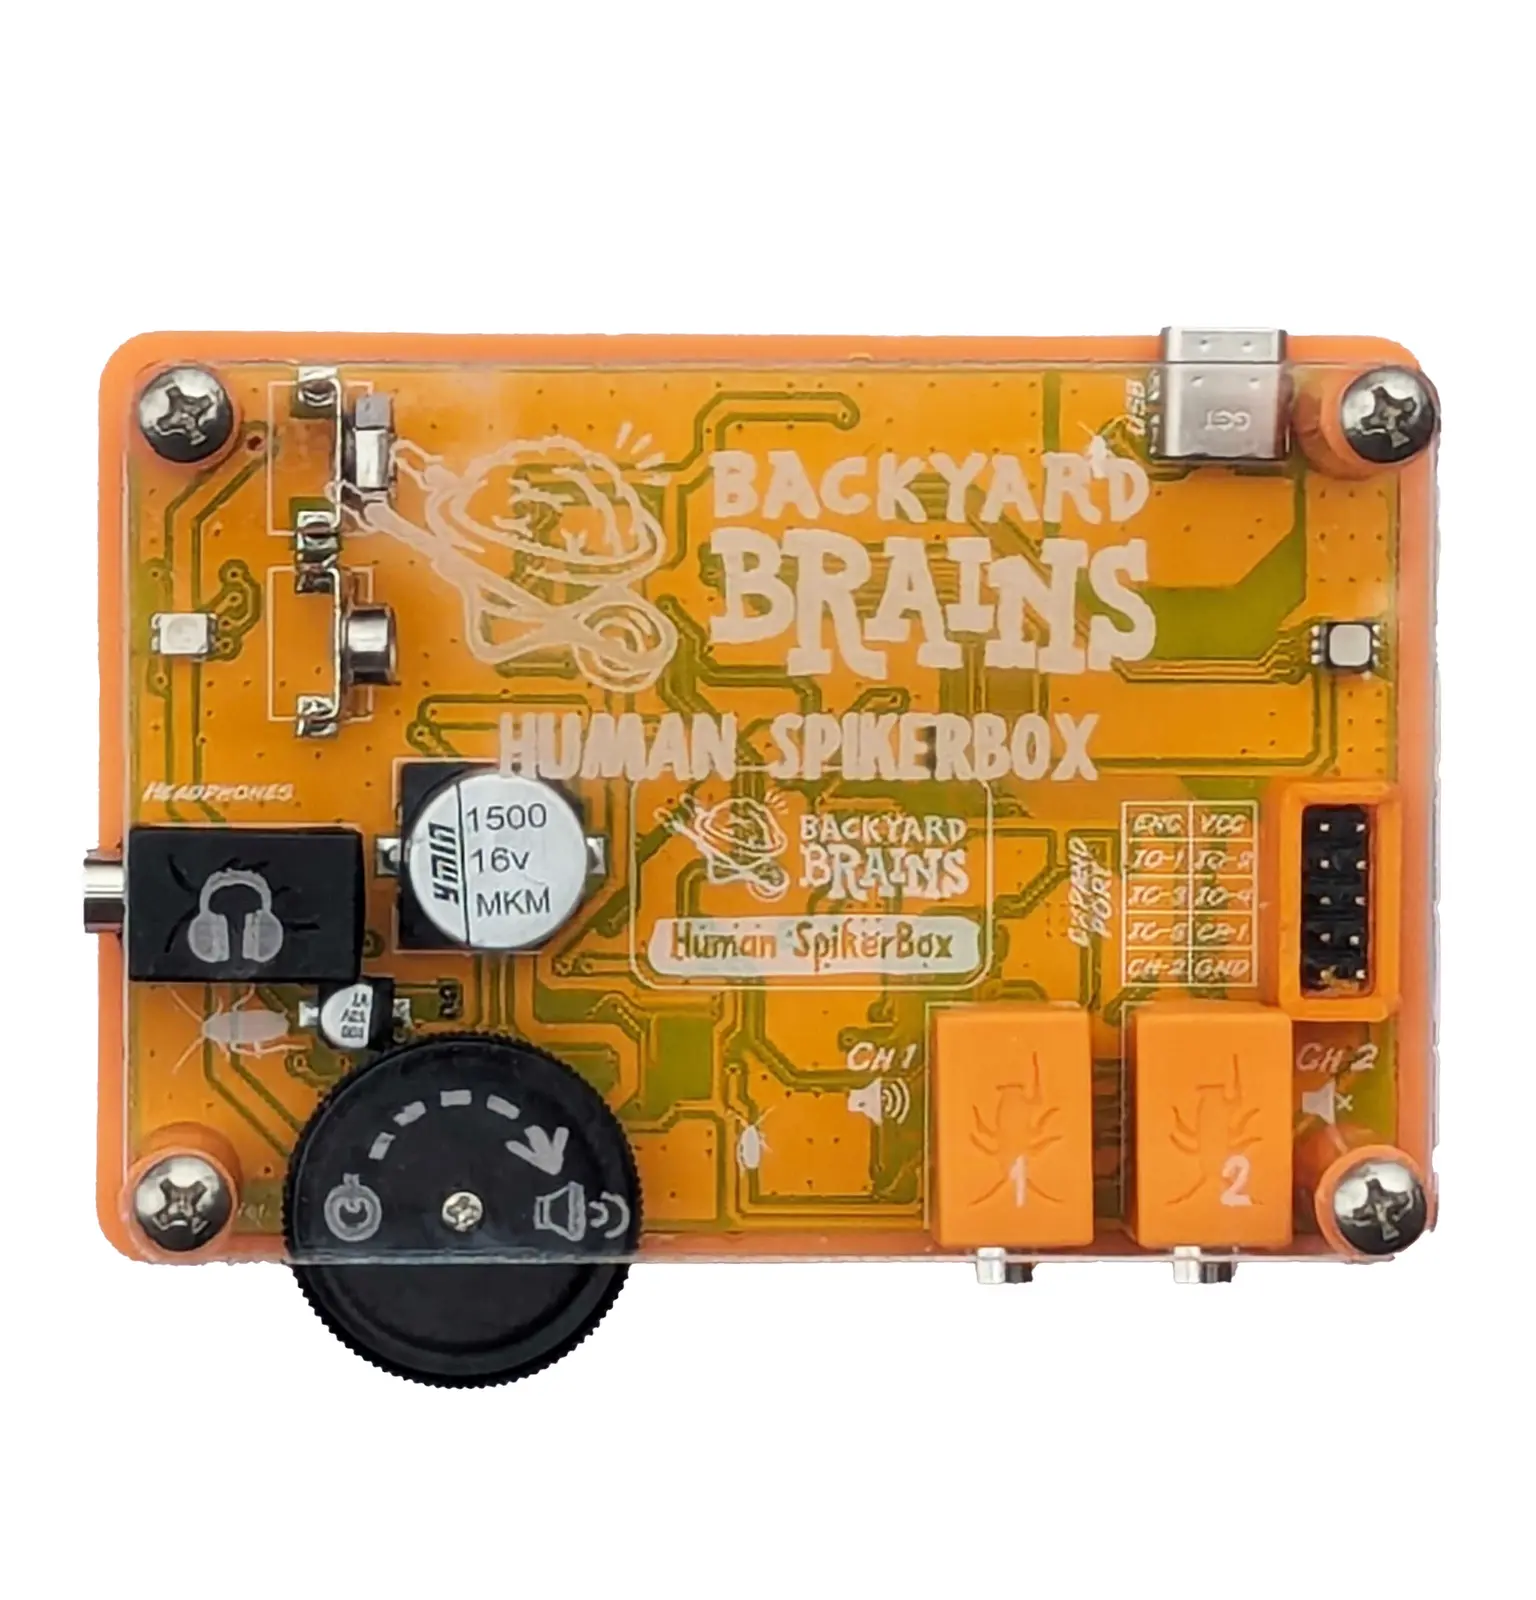
**Figura 1** Muscle Spikerbox, hardware educativo utilizado en la adquisición. Obtenido de: backyardbrains.com

El registro se realizó sobre la **cara anterior del antebrazo** (grupo flexor) para evaluar la relación entre la fuerza de agarre y la amplitud eléctrica. Esta configuración presenta características técnicas particulares que condicionan el procesamiento digital:

**1. La Naturaleza de la Frecuencia de Muestreo (44.1 kHz)**
El dispositivo SpikerBox transmite la señal bioeléctrica como audio analógico a la tarjeta de sonido. Por consiguiente, la frecuencia de muestreo se fija en **44,100 Hz**.
* **Implicación Metodológica:** Según **Merletti y Hermens (2000)**, la energía útil del EMG desaparece después de los 400-500 Hz. Esto nos deja con un exceso de ancho de banda (>20 kHz) dominado por ruido térmico. A diferencia del reporte original que utiliza la señal cruda, este estudio aplica un sub-muestreo lógico y filtrado estricto para aislar la banda fisiológica.

**2. Ubicación de Electrodos y Diafonía (Crosstalk)**
Según el reporte de adquisición, los electrodos se situaron en el vientre muscular anterior del antebrazo. Dado que el antebrazo contiene múltiples fascículos musculares en un volumen reducido, y siguiendo lo expuesto por **Mogk y Keir (2003)**, la señal registrada debe interpretarse como la actividad del **compartimento flexor global** y no de un músculo aislado. La diafonía es inevitable en esta configuración, por lo que el análisis de la envolvente representará la fuerza de agarre neta.

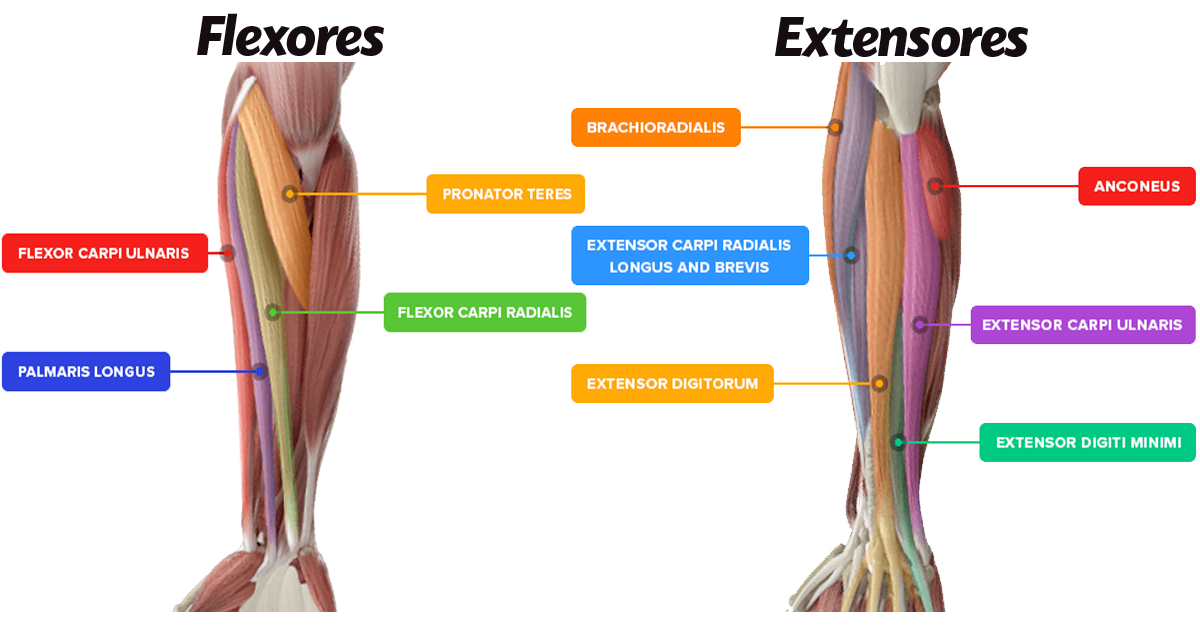
**Figura 2** Extensores y flexores del antebrazo. Obtenida de: https://academiarobertocastellano.com/wp-content/uploads/2023/09/antebrazos-fisonoai.png

**3. Interferencia y Desplazamiento (DC Offset)**
Al tratarse de una interfaz de audio con cables sin blindaje (*unshielded*), la señal presenta un **desplazamiento de DC** (voltaje de polarización del micrófono) y contaminación por frecuencia de línea (60 Hz) debido al efecto antena del cuerpo del sujeto.


## 6.3 Frecuencia de Muestreo y Contenido Espectral

La decisión sobre qué frecuencia de muestreo ($F_s$) utilizar no es arbitraria; debe fundamentarse estrictamente en el **Teorema de Muestreo de Nyquist-Shannon**. Este teorema establece que, para reconstruir una señal analógica sin pérdida de información, la frecuencia de muestreo debe ser, al menos, el doble de la frecuencia máxima contenida en la señal ($F_s \geq 2 \cdot f_{max}$). Si no se cumple esta condición, ocurre el fenómeno de *aliasing*, donde los componentes de alta frecuencia se "doblan" y aparecen falsamente como frecuencias bajas, corrompiendo los datos irreversiblemente (**Widmann et al., 2015**). 

Sin embargo, el $f_{max}$ fisiológico varía drásticamente entre el cerebro y el músculo, dictando requisitos de adquisición muy distintos:

* **EEG (Análisis de ritmos, 128 Hz - 256 Hz):**
    En el contexto del análisis de estados cognitivos básicos, el ancho de banda de interés es limitado. **Cohen (2014)** señala que la inmensa mayoría de la potencia espectral relevante del EEG (ritmos Delta, Theta, Alfa y Beta) se concentra entre los 2 y 40 Hz, decayendo significativamente por encima de los 40-50 Hz. 
    Por consiguiente, una frecuencia de muestreo de **128 Hz** (Nyquist para 64 Hz) suele ser suficiente para capturar fidedignamente estos ritmos oscilatorios sin introducir una carga computacional innecesaria ni ruido de alta frecuencia. Aunque existen componentes gamma (>30 Hz), para muchas aplicaciones clínicas y cognitivas estándar, el rango 2-45 Hz es el "estándar de oro" (**Nunez & Srinivasan, 2006**).

* **EMG (Análisis morfológico, > 1 kHz - 44.1 kHz):**
    La dinámica temporal del tejido muscular presenta un desafío mayor. **Merletti y Hermens (2000)** enfatizan que, si bien la contracción mecánica visible es un evento lento, el componente eléctrico subyacente (los Potenciales de Acción de Unidad Motora o MUAPs) contiene transitorios rápidos con contenido espectral significativo que se extiende hasta los **400-500 Hz**. 
    Más aún, la composición de fibras (lentas vs. rápidas) varía entre músculos, lo que altera sus características espectrales. Para caracterizar la morfología precisa de estos "spikes" individuales y realizar análisis finos de la señal cruda (evitando el *aliasing* en los componentes rápidos de los MUAPs), se requieren tasas de muestreo elevadas.

    > **Contexto Específico del Estudio:** Si bien el estándar clínico para EMG de superficie suele situarse entre 1 y 2 kHz, el uso de interfaces de audio para la adquisición (como se describió en la sección 6.2.1) impone una frecuencia de **44.1 kHz**. Esto representa un *sobremuestreo* masivo respecto a la fisiología, lo cual garantiza la captura íntegra de los eventos rápidos, pero obliga a un filtrado riguroso del ruido de alta frecuencia presente en la banda excedente (**McKiernan, 2025**). Utilizar una tasa típica de EEG (ej. 128 Hz) en este contexto sería catastrófico: destruiría la morfología de los picos y falsearía la estimación total de la energía muscular.

## 6.4 Ejemplos de registros. 


Antes de trabajar con nuestros propios datos, es útil observar cómo lucen registros típicos de EMG de antebrazo reportados en la literatura.

### Ejemplo de la literatura: sEMG de antebrazo durante gestos de mano

Ozdemir et al. (2022) publicaron un dataset abierto (CC BY 4.0) de señales EMG de superficie de 4 canales registradas desde los músculos del antebrazo de 40 participantes. Los electrodos Ag/AgCl se colocaron sobre cuatro músculos del antebrazo (flexor carpi radialis, extensor carpi radialis, flexor digitorum superficialis y extensor digitorum) mientras los participantes ejecutaban 10 gestos distintos de la mano. El sistema de adquisición fue un BIOPAC MP36 a 1000 Hz de frecuencia de muestreo.

En la señal cruda de EMG del antebrazo se observan las siguientes características típicas:

1. **Períodos de reposo**: La señal tiene una amplitud muy baja, cercana a la línea base, con solo ruido de fondo del amplificador.

2. **Ráfagas de activación (bursts)**: Durante la contracción muscular (flexión de muñeca, agarre, etc.), la señal muestra ráfagas de alta amplitud. La amplitud cruda de EMG reportada oscilaba entre −10 y 10 mV.

3. **Naturaleza interferencial**: A diferencia del EEG donde vemos oscilaciones cuasi-periódicas, el EMG crudo parece "ruido" denso y rápido. Esto es porque es la suma de muchos potenciales de acción de unidades motoras (MUAPs) disparando de manera asincrónica.

4. **Diferencias entre canales**: Un mismo gesto activa distintos músculos con intensidades diferentes. Por ejemplo, la flexión de muñeca produce mayor actividad en el canal del flexor carpi radialis que en el del extensor.

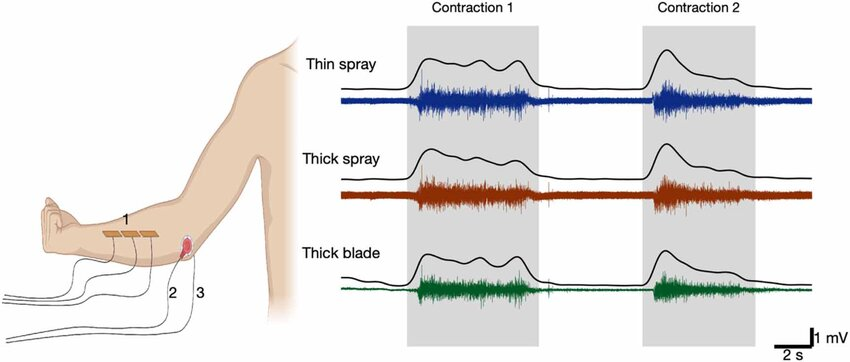!

**Figura 3** Ejemplo de registro de sEMG. Obtenida de Shankar (2023)

**Ahora veamos nuestros propios registros:**

En nuestros datos, usamos un equipo Backyard Brains con electrodos de superficie sobre el músculo de la pantorrilla. Aunque no tenemos el voltaje calibrado en mV exactos (los datos pasan por el codec de audio), lo que importa para nuestro análisis es el **cambio relativo en amplitud**: cuándo el músculo se activa y cuándo está en reposo, y cómo cambia la magnitud de esa activación.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, filtfilt, iirnotch, hilbert
from scipy import signal
import wave, warnings, sys, platform
from pathlib import Path

warnings.filterwarnings("ignore", category=RuntimeWarning)
plt.rcParams["figure.figsize"] = (10, 4)

# Rutas de datos
EEG_CSV = '/Users/vazquezperez/Documents/DianaTesis/Datos/EEG/H24_OC_OA.csv'
EMG_WAV = '/Users/vazquezperez/Documents/DianaTesis/Datos/EMG/S1_EMG_leftHand_gripIntermittent.wav'

In [4]:
# --- Cargar EEG (canal O1) ---
df_eeg = pd.read_csv(EEG_CSV)
fs_eeg = 128
eeg_O1 = df_eeg.iloc[:, 6].values  # índice 6 = canal O1

t_eeg = np.arange(len(eeg_O1)) / fs_eeg
print("EEG cargado:", df_eeg.shape, "(filas, canales)")
print("Canal analizado: O1 (no promedio)")

# --- Cargar EMG ---
record = wave.open(EMG_WAV, "r")
numChannels = record.getnchannels()
N = record.getnframes()
fs_emg = record.getframerate()
dstr = record.readframes(N * numChannels)
waveData = np.frombuffer(dstr, np.int16).astype(np.float64)
timeEMG = np.linspace(0, len(waveData)/fs_emg, num=len(waveData))

print(f"EMG cargado: {numChannels} canal(es), fs={fs_emg} Hz, duración={len(waveData)/fs_emg:.2f} s")

EEG cargado: (23127, 14) (filas, canales)
Canal analizado: O1 (no promedio)
EMG cargado: 1 canal(es), fs=44100 Hz, duración=63.15 s


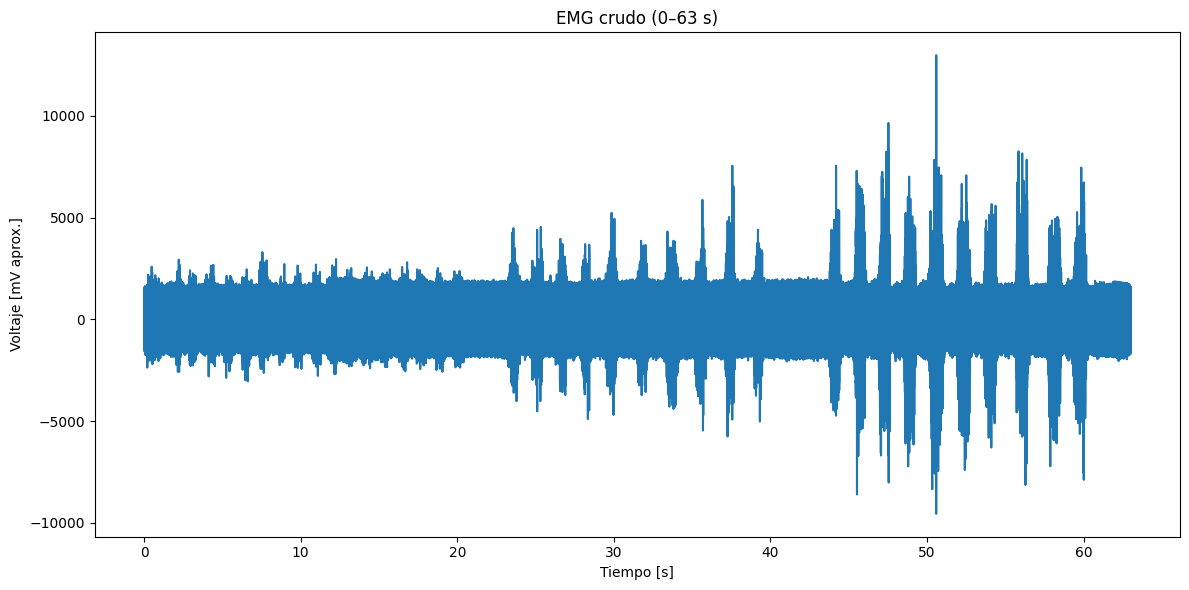

In [5]:

plt.figure(figsize=(12,6))


# EMG crudo (0–63 s)
t0, tf = 0, 63
i0, i1 = int(t0*fs_emg), int(tf*fs_emg)

plt.plot(timeEMG[i0:i1], waveData[i0:i1])
plt.title("EMG crudo (0–63 s)")
plt.xlabel("Tiempo [s]")
plt.ylabel("Voltaje [mV aprox.]")

plt.tight_layout()
plt.show()

###  Limitaciones del Registro en Antebrazo: El Fenómeno de Diafonía (Crosstalk)

A diferencia del filtrado de ruido eléctrico (60 Hz), la contaminación por actividad muscular adyacente no puede eliminarse mediante filtrado espectral convencional, dado que las fuentes de "ruido" (músculos vecinos) comparten el mismo ancho de banda frecuencial que la señal objetivo (**Mogk & Keir, 2003**).

En el caso específico del antebrazo, el volumen conductor actúa como un medio dispersivo. Al utilizar electrodos de superficie con una distancia inter-electrodo fija (configuración SpikerBox), el "campo de visión" del sensor abarca inevitablemente múltiples fascículos musculares.

**Implicación para el Análisis:**
La señal procesada debe interpretarse como la actividad del **compartimento muscular anterior/posterior** global, y no como la actividad aislada de un músculo anatómico único (ej. *Flexor Carpi Radialis*). Esto es aceptable para aplicaciones de control (como prótesis o interfaces hombre-máquina) donde el objetivo es detectar la intención de movimiento general, pero representa una limitante para estudios de biomecánica fina de dedos individuales (**De Luca, 1997**).

### Nota sobre la Fuente de los Datos y el Protocolo

El protocolo experimental para la adquisición de las señales de EMG analizadas en este cuaderno se basó en el **Capítulo 7** de **McKiernan et al. (2025)**. Dicho protocolo establece el uso del equipo *Backyard Brains SpikerBox* para registrar la actividad de los músculos superficiales del antebrazo durante tareas de dinamometría isométrica.

Es importante notar que, si bien la fuente original describe el procedimiento fisiológico y de adquisición, no detalla la cadena de pre-procesamiento digital necesaria para limpiar la señal de audio (44.1 kHz) y aislar la envolvente de fuerza. Por lo tanto, el **pipeline de procesamiento** detallado en las secciones siguientes (Eliminación de DC, Filtrado SOS y Envolvente) es una implementación metodológica propia de este trabajo, diseñada para cumplir con los estándares de calidad de señal descritos por **Merletti y Hermens (2000)**, adaptados a las limitaciones del hardware educativo utilizado.

## 6.5 Filtrado: Definición de la Ventana de Observación

Como ocurre con cualquier registro electrofisiológico extracelular, las señales crudas de EEG y EMG están contaminadas por ruido ambiental, artefactos biológicos y deriva instrumental. **Widmann et al. (2015)** enfatizan que el filtrado digital no es simplemente "limpiar" la señal, sino definir la **ventana de observación** fisiológica pertinente, descartando información que, aunque real, no corresponde al fenómeno de interés (como el ruido muscular en un registro cerebral).

Aunque el objetivo común es mejorar la Relación Señal-Ruido (SNR), los rangos de corte (*cutoff frequencies*) difieren radicalmente debido a la naturaleza espectral discutida en la sección anterior.

### 1. Electroencefalograma (EEG): La ventana cognitiva
Como exploramos en el **Notebook 2** de este compendio, la mayor parte de la actividad oscilatoria vinculada a procesos cognitivos básicos reside en frecuencias bajas.
* **Filtro Paso Banda: 2 – 45 Hz**
    * **Paso Alto (> 2 Hz):** Elimina la deriva lenta (DC drift) causada por la sudoración o movimientos lentos de los electrodos, así como componentes Delta muy lentos que a menudo son artefactos en sujetos despiertos.
    * **Paso Bajo (< 45 Hz):** Preserva intactos los ritmos **Alfa (8-13 Hz)** y **Beta (14-30 Hz)**. Crucialmente, cortar antes de los 50 Hz tiene un doble beneficio: elimina gran parte de la contaminación muscular (que es de banda ancha y alta frecuencia) y atenúa naturalmente la interferencia de línea eléctrica (60 Hz).
    * *Nota:* Si el objetivo fuera investigar oscilaciones Gamma altas (>40 Hz), este filtro sería inapropiado, pero para el análisis estándar, 45 Hz es un límite seguro para garantizar la pureza de la señal neural (**Cohen, 2014**).

### 2. Electromiograma (EMG): La ventana de potencia motora
El EMG requiere una ventana mucho más amplia para capturar la energía de los Potenciales de Acción de Unidad Motora (MUAP).
* **Filtro Paso Banda: 10 – 400 Hz**
    * **Paso Alto (> 10-20 Hz):** Según **Merletti y Hermens (2000)**, esto es crítico para eliminar **artefactos de movimiento**. La energía mecánica del movimiento de la extremidad genera grandes fluctuaciones de baja frecuencia que no son actividad eléctrica muscular real.
    * **Paso Bajo (< 400-500 Hz):** Define el límite superior de la energía de los MUAP y elimina ruido electrónico de alta frecuencia.

### La problemática de la línea eléctrica (60 Hz)

La interferencia de la red eléctrica (60 Hz en México/USA, 50 Hz en Europa) presenta un reto distinto para cada señal:
* **En EEG (2-45 Hz):** Al aplicar un filtro paso bajo en 45 Hz, la interferencia de 60 Hz queda fuera de la banda de paso y es atenuada automáticamente.
* **En EMG (10-400 Hz):** Los 60 Hz caen justo en medio de la banda de información útil. No podemos simplemente usar un filtro paso bajo. Aquí es necesario aplicar un **Filtro Notch** (filtro de rechazo de banda estrecha) centrado específicamente en 60 Hz.

> **Reto de investigación:** El filtro Notch estándar puede distorsionar la fase de la señal alrededor de los 60 Hz. En investigación avanzada, se sugieren métodos como la interpolación espectral o regresión de ruido (ej. algoritmo CleanLine) para sustraer el ruido de línea sin "agujerear" el espectro. Para efectos de este ejercicio, utilizaremos un Notch digital estándar.

## Un buen ejemplo de EEG y EMG
Aquí presentamos el ejemplo que tenemos de los registros. Del protocolo de Angélica Rubio García (2020) obtuvimos datos sobre el antebrazo. Como se mencionó anteriormente, tenemos el fenómeno de cross talk y distintas limitaciones que muestran ruidos en las zonas de relajación del electromiograma. Es necesario aplicar el filtrado para trabajar con una señal más limpia. Se muestra un ejemplo del registro en crudo con una superposición del registro con un filtrado en dos etapas:
**1. Filtrado paso banda (10–400 Hz).**  
El EMG concentra la mayor parte de su energía en este rango de frecuencias. Los componentes por debajo de 10 Hz suelen provenir de artefactos de movimiento o del desplazamiento mecánico del electrodo, mientras que los que superan 400 Hz corresponden generalmente a ruido electrónico. El filtrado paso banda atenúa ambos extremos, conservando las descargas rápidas de fibras musculares superficiales. Al observar la señal tras este paso, se nota cómo desaparecen las oscilaciones lentas de la línea base, quedando un trazo más centrado en torno a cero y con picos más definidos.  

**Filtrado Notch.**  
Además del filtrado paso banda, existe un artefacto específico que merece atención individual: la interferencia de la red eléctrica. En México, la corriente alterna opera a 60 Hz, y esta frecuencia se acopla capacitivamente a los cables, electrodos y al propio cuerpo del sujeto, apareciendo como una oscilación sinusoidal persistente superpuesta a la señal biológica. Merletti y Hermens (2000) identifican la interferencia de línea eléctrica como una de las principales fuentes de ruido en registros de EMG de superficie, junto con los artefactos de movimiento y el ruido inherente del amplificador.

El problema es que 60 Hz cae dentro de la banda de interés del EMG (10–400 Hz), por lo que el filtro paso banda no la elimina. Se necesita un filtro que remueva únicamente esa frecuencia puntual sin afectar a sus vecinas. Ese es el filtro notch (también llamado band-stop o rechaza-banda): un filtro muy estrecho que atenúa exclusivamente una frecuencia objetivo y sus armónicos (120 Hz, 180 Hz, etc.) dejando intacto el resto del espectro. Widmann et al. (2015) discuten en detalle el diseño práctico de filtros digitales para datos electrofisiológicos y recomiendan que los filtros notch sean lo más estrechos posible para minimizar la distorsión del contenido espectral biológico adyacente.

El parámetro que controla qué tan estrecho es el notch se llama factor de calidad (Q). Un Q alto (por ejemplo, Q = 30) produce un notch muy angosto (~2 Hz de ancho) que elimina los 60 Hz con mínima distorsión del contenido muscular adyacente. Un Q bajo (por ejemplo, Q = 5) produce un notch más ancho que podría afectar componentes musculares reales cercanos a 60 Hz. De acuerdo con Konrad (2005), la eliminación precisa de la interferencia de línea es especialmente crítica cuando se registran músculos pequeños o cuando la relación señal-ruido es baja, situaciones en las que la contaminación de 60 Hz puede tener una amplitud comparable a la señal muscular de interés.
En nuestro caso, aplicamos primero el paso banda y luego el notch a 60 Hz. El orden importa conceptualmente aunque matemáticamente ambos son lineales: al aplicar el paso banda primero, eliminamos la mayor parte del ruido fuera de banda, y el notch solo necesita encargarse de la interferencia puntual de línea. Basmajian y De Luca (1985) recomiendan esta secuencia como parte del protocolo estándar de acondicionamiento de señales EMG de superficie.


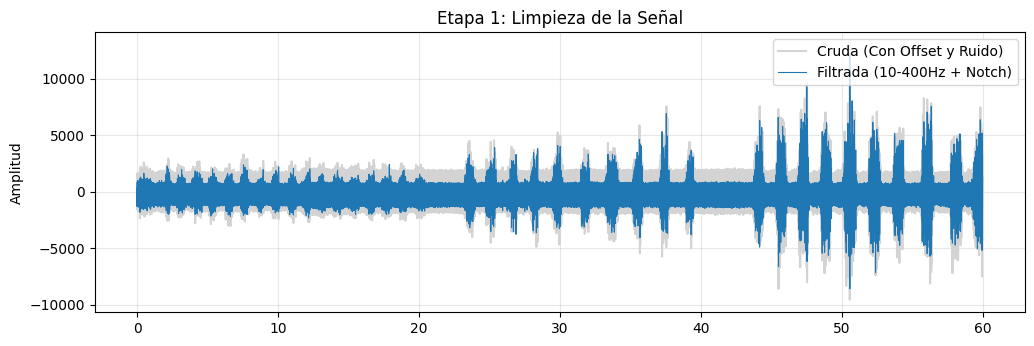

In [6]:

def pipeline_emg_completo(senal_cruda, fs):
    """
    Aplica la tubería completa de corrección para EMG de audio (Backyard Brains).
    
    Args:
        senal_cruda (array): Datos del archivo WAV.
        fs (float): Frecuencia de muestreo (ej. 44100).
        
    Returns:
        dict: Diccionario con 'limpia' (filtrada) y 'envolvente' (fuerza).
    """
    # 1. CORRECCIÓN DE OFFSET (DC REMOVAL)
    # Fundamental para que el SNR y la rectificación funcionen
    senal_centrada = senal_cruda - np.mean(senal_cruda)
    
    # 2. FILTRADO ESPECTRAL (LIMPIEZA)
    nyq = 0.5 * fs
    
    # A. Paso Banda (10 - 400 Hz) usando SOS (Estabilidad numérica)
    sos_band = butter(4, [10/nyq, 400/nyq], btype='band', output='sos')
    emg_bandpass = sosfiltfilt(sos_band, senal_centrada)
    
    # B. Notch (60 Hz) para ruido eléctrico
    b_notch, a_notch = iirnotch(60/nyq, 30) # Q=30 es selectivo
    emg_limpia = filtfilt(b_notch, a_notch, emg_bandpass)
    
    
    
    return {
        'limpia': emg_limpia,
    }

# EJECUCIÓN DEL PIPELINE 

# Procesamos los datos cargados previamente
resultados = pipeline_emg_completo(waveData, fs_emg)
emg_final = resultados['limpia']

# VISUALIZACIÓN DE LA CORRECCIÓN 

# Definimos una ventana de tiempo interesante para ver el detalle
# (Usamos la zona de fuerza antes definido: 40s a 50s aprox)
t_inicio, t_fin = 0, 60
idx = (int(t_inicio*fs_emg), int(t_fin*fs_emg))

t_plot = timeEMG[idx[0]:idx[1]]
raw_plot = waveData[idx[0]:idx[1]]
clean_plot = emg_final[idx[0]:idx[1]]

plt.figure(figsize=(12, 8))

# 1. Señal Cruda vs Limpia
plt.subplot(2, 1, 1)
plt.plot(t_plot, raw_plot, color='lightgray', label='Cruda (Con Offset y Ruido)')
plt.plot(t_plot, clean_plot, color='#1f77b4', linewidth=0.8, label='Filtrada (10-400Hz + Notch)')
plt.title('Etapa 1: Limpieza de la Señal')
plt.ylabel('Amplitud')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)


Nota para EEG: En el caso del EPOC X, el filtrado notch ya está implementado de forma digital dentro del hardware del equipo. Según las especificaciones técnicas del fabricante (Emotiv, 2020), el EPOC X incorpora filtros notch digitales a 50 y 60 Hz de manera integrada, además de un filtro Sinc de 5° orden. Esto significa que los datos de EEG que descargamos del EPOC X ya llegan sin interferencia de línea, y no necesitamos aplicar un notch adicional en nuestro pre-procesamiento con Python. En contraste, el Muscle SpikerBox entrega la señal con filtrado analógico de paso banda (300–1200 Hz según el modelo) pero sin notch dedicado, por lo que debemos aplicarlo nosotros en el software cuando la banda de interés incluye los 60 Hz.

## 6.6 Procesamiento Adicional.

La divergencia metodológica es crítica en esta etapa:

* **EEG:** Buscamos caracterizar oscilaciones. **No se rectifica**, ya que la fase positiva/negativa es parte de la onda.
* **EMG (Rectificación y Envolvente):** La señal cruda es estocástica (suma de eventos aleatorios). Para cuantificar la "fuerza" o "activación", se debe **rectificar** (valor absoluto) y calcular la envolvente (RMS o filtro paso bajo).

## 6.7  Protocolo de procesamiento EMG

El electromiograma de superficie es un registro eléctrico altamente informativo, pero también muy vulnerable a artefactos. La señal cruda contiene tanto la actividad muscular como múltiples fuentes de ruido: movimiento de los electrodos, desplazamiento de la piel, interferencia de la red eléctrica e incluso ruido propio del amplificador. Por esta razón, no es posible interpretar directamente el trazo inicial. En su lugar, se aplica un **protocolo de procesamiento estandarizado** cuyo objetivo es aislar la actividad muscular real y representarla de manera clara.  

De acuerdo con Merletti y Hermens (2000), así como con De Luca (1997), este protocolo consta de tres pasos fundamentales:  



**2. Rectificación.**  
La señal EMG es alternante: oscila entre valores positivos y negativos en torno a cero. Esto significa que, si se calculara directamente una media, las descargas musculares tenderían a cancelarse entre sí. Para evitarlo, se aplica la rectificación, que consiste en tomar el valor absoluto de cada muestra. El resultado es un trazo únicamente positivo, en el que cada potencial de acción suma en la misma dirección. Esta operación tiene un sentido fisiológico claro: lo que interesa es la magnitud total de la contracción, no la polaridad de las descargas.  

**3. Cálculo de la envolvente.**  
Una vez rectificada, la señal puede suavizarse para representar de manera continua el nivel de activación muscular. La envolvente puede calcularse con un promedio móvil o con la transformada de Hilbert. Este último método ofrece una curva más estable y de la misma longitud que la señal original, lo que lo convierte en una opción robusta para visualizar la dinámica de la contracción. Al graficar la envolvente, se aprecia cómo los periodos de contracción destacan con claridad sobre el fondo, facilitando la identificación de fases activas e inactivas.  

En conjunto, este flujo de procesamiento —filtrado, rectificación y envolvente— convierte un registro ruidoso y oscilante en una representación que resume la fuerza y duración de la contracción muscular. Cada paso se justifica no solo desde el punto de vista técnico, sino también fisiológico, mostrando cómo los métodos digitales permiten dar forma cuantitativa a fenómenos biológicos.


In [7]:
nyq_emg = fs_emg / 2
b_emg, a_emg = butter(3, [10/nyq_emg, 400/nyq_emg], btype='band')
emg_filtered = filtfilt(b_emg, a_emg, waveData)
emg_rect = np.abs(emg_filtered)

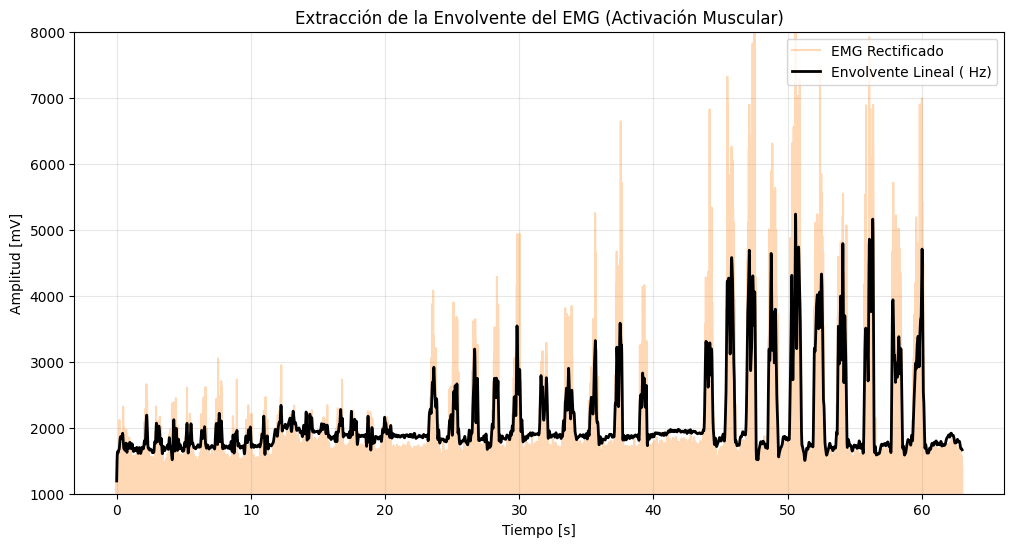

In [8]:

# DEFINICIÓN DE LA ENVOLVENTE LINEAL 

def obtener_envolvente_lineal(senal_rectificada, fs, corte=8, orden=4):
    """
    Calcula la envolvente suave aplicando un filtro paso bajo a la señal rectificada.
    
    
    """
    nyquist = 0.5 * fs
    low = corte / nyquist
    b, a = butter(orden, low, btype='low')
    
    # Usamos filtfilt para evitar el desfase temporal (phase shift)
    # Esto asegura que la envolvente se alinee perfectamente con los picos.
    return filtfilt(b, a, senal_rectificada)

#APLICACIÓN 

# 1. Calculamos la envolvente (Asumiendo corte de 6Hz para suavidad)
emg_rect = np.abs(emg_filtered)
emg_envelope = obtener_envolvente_lineal(emg_rect, fs_emg, corte=8)

# VISUALIZACIÓN 

plt.figure(figsize=(12, 6))

# Graficamos la señal rectificada de fondo (más clara)
plt.plot(timeEMG[i0:i1], emg_rect[i0:i1], color="tab:orange", alpha=0.3, label='EMG Rectificado')

# Graficamos la envolvente encima (línea sólida y oscura)
plt.plot(timeEMG[i0:i1], emg_envelope[i0:i1]*2.5, color="black", linewidth=2, label='Envolvente Lineal ( Hz)') #multiplicada por 2.5

plt.title("Extracción de la Envolvente del EMG (Activación Muscular)")
plt.ylim(1000,8000)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [mV]") # Ajusta si normalizaste
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

## 6.8 Análisis para ver estado fisiológico.

La divergencia en las rutas de procesamiento refleja la distinta naturaleza de la información biológica: el EEG se analiza como una **medida de estado**, mientras que el EMG se analiza como una **medida de acción** (Cohen, 2014; Merletti & Hermens, 2000).

Una vez completado el pre-procesamiento diferenciado (filtrado oscilatorio para EEG y rectificación para EMG), se aplican métricas específicas para traducir el voltaje en variables fisiológicas interpretables. De acuerdo a lo que se quiera estudiar va a ser el tipo de análisis.

### Métricas para EEG: Dominio de la Frecuencia

Dado el carácter estocástico y oscilatorio del EEG, Cohen (2014) sugiere priorizar métricas espectrales:

- **Densidad Espectral de Potencia (PSD):** Cuantifica cómo se distribuye la potencia de la señal a través de las frecuencias ($\mu V^2 / Hz$). Se calcula típicamente con el método de Welch, que promedia periodogramas de segmentos superpuestos de la señal para reducir la varianza del estimado (Welch, 1967).

- **Potencia Relativa de Banda:** Es la relación entre la potencia en una banda específica (ej. Alfa, 8–13 Hz) y la potencia total. Nunez y Srinivasan (2006) la describen como el estándar para medir la desincronización relacionada con eventos (ERD) o el bloqueo alfa visual. Por ejemplo, al cerrar los ojos, la potencia relativa en alfa aumenta; al abrirlos, disminuye. Este cambio relativo es más robusto que la potencia absoluta porque normaliza las diferencias individuales en grosor craneal y conductividad del cuero cabelludo.

In [9]:
# Parámetros generales
fs = 128  # Hz
canal = 6  # Canal O1
ti_abiertos, tf_abiertos = 105, 120  # Intervalo OA

# Ruta del archivo
ruta = "/Users/vazquezperez/Documents/DianaTesis/Datos/EEG/H24_OC_OA.csv"

# Carga y filtrado Butterworth (2–45 Hz) 
datos = pd.read_csv(ruta)
lowcut, highcut = 2, 45
orden = 4
b, a = signal.butter(orden, [lowcut/(fs/2), highcut/(fs/2)], btype='bandpass')
eeg_filtered = signal.filtfilt(b, a, datos.to_numpy(), axis=0)
eeg_filtered = pd.DataFrame(eeg_filtered, columns=datos.columns)


In [10]:
# Ejemplo: PSD y Potencia Relativa de Banda para EEG 
from scipy.signal import welch

fm = 128

# Extraer canal O1 como array numpy 1D
canal_O1 = eeg_filtered.iloc[:, 6].to_numpy()  # columna 6 = O1

# Calcular PSD del segmento EEG
nperseg_eeg = int(2 * fm)  # ventana de 2 segundos
f_eeg, Pxx_eeg = welch(canal_O1, fs=fm, nperseg=nperseg_eeg)

# Definir bandas de frecuencia (Nunez & Srinivasan, 2006)
bandas = {
    'Delta (1-4 Hz)':  (1, 4),
    'Theta (4-8 Hz)':  (4, 8),
    'Alfa (8-13 Hz)':  (8, 13),
    'Beta (14-30 Hz)': (14, 30),
    'Gamma (30-45 Hz)':(30, 45)
}

# Calcular potencia absoluta y relativa por banda
potencia_total = np.trapz(Pxx_eeg[(f_eeg >= 1) & (f_eeg <= 45)],
                          f_eeg[(f_eeg >= 1) & (f_eeg <= 45)])

print("Potencia Relativa de Banda (EEG — canal O1):")
print("-" * 40)
potencias = {}
for nombre, (fl, fh) in bandas.items():
    mask_banda = (f_eeg >= fl) & (f_eeg <= fh)
    pot_banda = np.trapz(Pxx_eeg[mask_banda], f_eeg[mask_banda])
    pot_rel = (pot_banda / potencia_total) * 100
    potencias[nombre] = pot_rel
    print(f"  {nombre:20s} → {pot_rel:5.1f} %")

Potencia Relativa de Banda (EEG — canal O1):
----------------------------------------
  Delta (1-4 Hz)       →   6.6 %
  Theta (4-8 Hz)       →   8.4 %
  Alfa (8-13 Hz)       →  73.3 %
  Beta (14-30 Hz)      →   7.4 %
  Gamma (30-45 Hz)     →   2.7 %


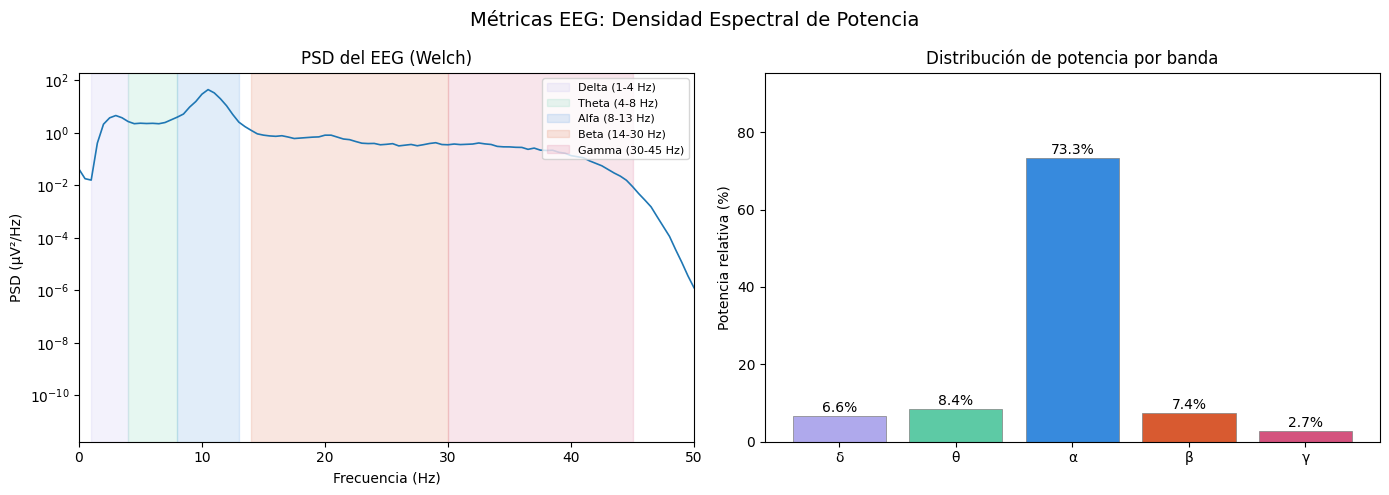

In [11]:
# Visualización: PSD con bandas coloreadas 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Métricas EEG: Densidad Espectral de Potencia', fontsize=14)

# PSD completa con bandas sombreadas
ax1.semilogy(f_eeg, Pxx_eeg, color='tab:blue', linewidth=1.2)
colores = ['#AFA9EC', '#5DCAA5', '#378ADD', '#D85A30', '#D4537E']
for (nombre, (fl, fh)), c in zip(bandas.items(), colores):
    ax1.axvspan(fl, fh, alpha=0.15, color=c, label=nombre)
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('PSD (µV²/Hz)')
ax1.set_title('PSD del EEG (Welch)')
ax1.set_xlim(0, 50)
ax1.legend(fontsize=8, loc='upper right')

# Gráfica de barras de potencia relativa
nombres_cortos = ['δ', 'θ', 'α', 'β', 'γ']
valores = list(potencias.values())
bars = ax2.bar(nombres_cortos, valores, color=colores, edgecolor='gray', linewidth=0.5)
ax2.set_ylabel('Potencia relativa (%)')
ax2.set_title('Distribución de potencia por banda')
ax2.set_ylim(0, max(valores) * 1.3)
for bar, val in zip(bars, valores):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()



### Métricas para EMG: Dominio del Tiempo y Amplitud

El objetivo principal en EMG suele ser estimar la salida mecánica (fuerza) a partir de la actividad eléctrica. Merletti y Hermens (2000) recomiendan métricas de amplitud:

- **RMS (Root Mean Square):** Representa la raíz de la potencia media de la señal en una ventana de tiempo. En condiciones isométricas no fatigantes, el valor RMS muestra una correlación cuasi-lineal con la fuerza producida (De Luca, 1997). Matemáticamente:

$$\text{RMS} = \sqrt{\frac{1}{N} \sum_{i=1}^{N} x_i^2}$$

donde $x_i$ son las muestras de la señal EMG rectificada y $N$ es el número de muestras en la ventana.

- **iEMG (Integrated EMG):** Corresponde al área bajo la curva de la señal rectificada, utilizada para cuantificar el esfuerzo muscular total durante un intervalo de tiempo (Basmajian & De Luca, 1985). Es especialmente útil para comparar el esfuerzo entre contracciones de distinta duración cuando se normaliza por el tiempo:

$$\text{iEMG} = \sum_{i=1}^{N} |x_i| \cdot \Delta t$$

Ambas métricas requieren que la señal haya sido previamente filtrada y, en el caso del iEMG, rectificada. El RMS tiene la ventaja de no requerir rectificación explícita (la operación de elevar al cuadrado ya elimina el signo).

In [12]:
# Ejemplo: RMS e iEMG para EMG del antebrazo 

# RMS con ventana deslizante (De Luca, 1997)
ventana_ms = 250  # ventana de 250 ms (estándar para EMG isométrico)
ventana_muestras = int(ventana_ms / 1000 * fs_emg)

# Calcular RMS deslizante
emg_rms = np.array([
    np.sqrt(np.mean(emg_filtered[i:i+ventana_muestras]**2))
    for i in range(0, len(emg_filtered) - ventana_muestras, ventana_muestras // 4)
])
t_rms = np.linspace(timeEMG[0], timeEMG[-1], len(emg_rms))

# Calcular iEMG acumulado (Basmajian & De Luca, 1985)
dt_emg = 1.0 / fs_emg
emg_iemg = np.cumsum(np.abs(emg_filtered)) * dt_emg

print(f"Ventana RMS: {ventana_ms} ms ({ventana_muestras} muestras)")
print(f"RMS máximo: {np.max(emg_rms):.2f}")
print(f"iEMG total: {emg_iemg[-1]:.2f}")

Ventana RMS: 250 ms (11025 muestras)
RMS máximo: 2384.75
iEMG total: 52559.70


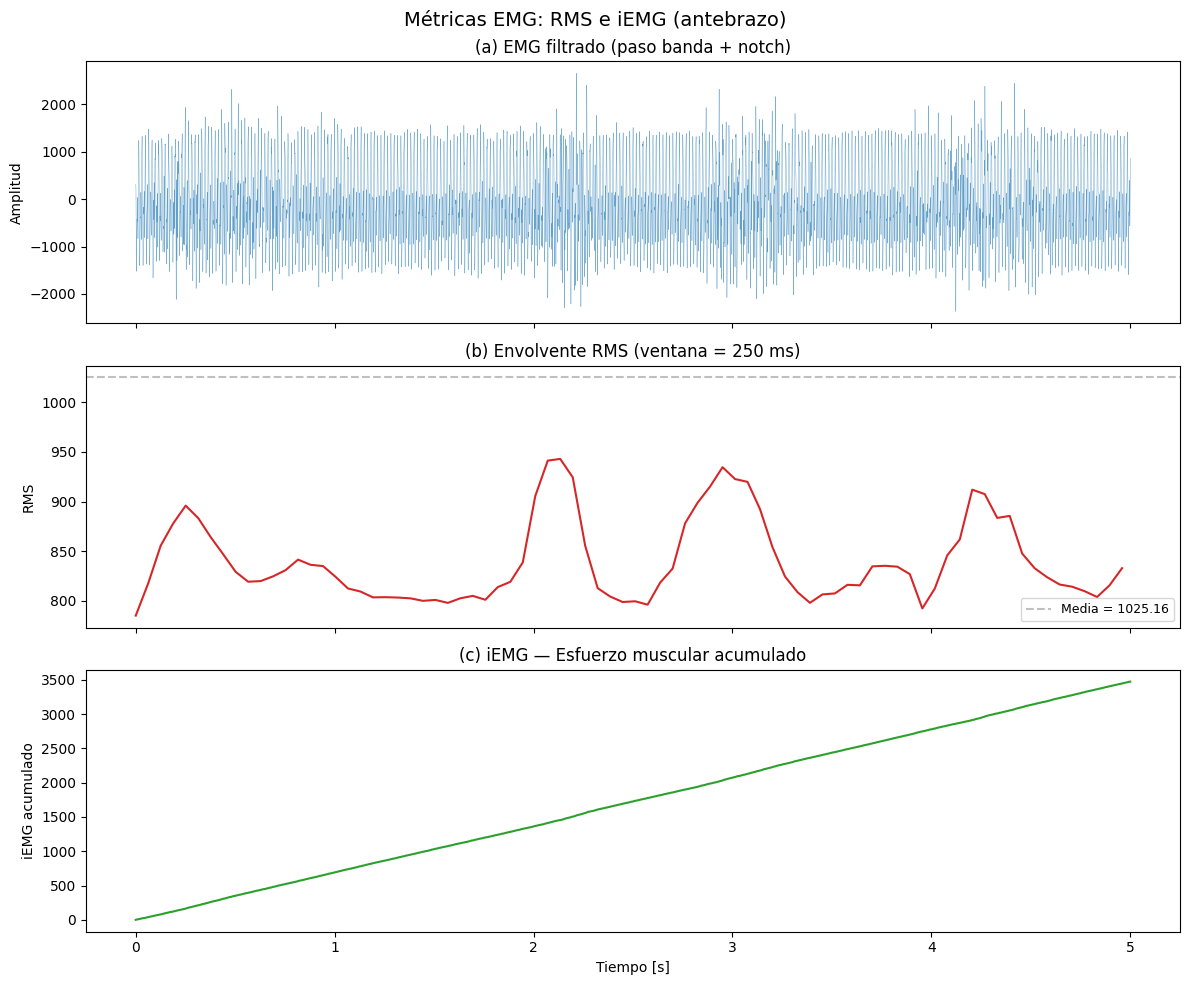

In [13]:
# --- Visualización: Métricas EMG ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle('Métricas EMG: RMS e iEMG (antebrazo)', fontsize=14)

# (a) Señal filtrada
t1_plot, t2_plot = 0, 5  # ajustar según duración de datos
mask_plot = (timeEMG >= t1_plot) & (timeEMG < t2_plot)
axes[0].plot(timeEMG[mask_plot], emg_filtered[mask_plot],
             color='tab:blue', linewidth=0.3, alpha=0.7)
axes[0].set_ylabel('Amplitud')
axes[0].set_title('(a) EMG filtrado (paso banda + notch)')

# (b) Envolvente RMS
mask_rms = (t_rms >= t1_plot) & (t_rms < t2_plot)
axes[1].plot(t_rms[mask_rms], emg_rms[mask_rms],
             color='tab:red', linewidth=1.5)
axes[1].set_ylabel('RMS')
axes[1].set_title(f'(b) Envolvente RMS (ventana = {ventana_ms} ms)')
axes[1].axhline(y=np.mean(emg_rms), color='gray', linestyle='--',
                alpha=0.5, label=f'Media = {np.mean(emg_rms):.2f}')
axes[1].legend(fontsize=9)

# (c) iEMG acumulado
mask_iemg = (timeEMG >= t1_plot) & (timeEMG < t2_plot)
axes[2].plot(timeEMG[mask_iemg], emg_iemg[mask_iemg],
             color='tab:green', linewidth=1.5)
axes[2].set_ylabel('iEMG acumulado')
axes[2].set_title('(c) iEMG — Esfuerzo muscular acumulado')
axes[2].set_xlabel('Tiempo [s]')

plt.tight_layout()
plt.show()

### Comparación directa: ¿qué le preguntamos a cada señal?

La siguiente tabla sintetiza cómo la pregunta que queremos responder determina la métrica que debemos usar. Nótese que no es intercambiable: calcular RMS de un EEG no tiene la misma interpretación fisiológica que calcular RMS de un EMG, y calcular PSD de un EMG, aunque es posible (y útil para estudios de fatiga), no es la métrica primaria para cuantificar la fuerza de contracción.

| Pregunta fisiológica | Señal | Métrica | Referencia |
|---|---|---|---|
| ¿En qué estado cognitivo está el sujeto? | EEG | Potencia relativa de banda (ej. α/β ratio) | Cohen (2014); Nunez & Srinivasan (2006) |
| ¿Hay desincronización por un evento? | EEG | ERD/ERS (cambio % en potencia de banda) | Cohen (2014) |
| ¿Cuánta fuerza está produciendo el músculo? | EMG | RMS (correlación cuasi-lineal con fuerza) | De Luca (1997); Merletti & Hermens (2000) |
| ¿Cuánto esfuerzo total hubo en un intervalo? | EMG | iEMG (área bajo la curva rectificada) | Basmajian & De Luca (1985) |
| ¿El músculo se está fatigando? | EMG | Desplazamiento de frecuencia mediana (PSD) | Merletti & Hermens (2000) |



In [14]:
# Tabla resumen de la síntesis comparativa (Tabla 6.8) 


sintesis = {
    'Etapa': ['Adquisición', 'Frecuencia de muestreo', 'Filtrado paso banda',
              'Procesamiento posterior', 'Métrica clave', 'Interpretación fisiológica'],
    'EEG': [
        'Electrodos en cuero cabelludo (10–100 µV)',
        '128 Hz (suficiente para ritmos < 45 Hz)',
        '2–45 Hz (aislar oscilaciones)',
        'Rectificar y envolvente NO aplica',
        'Potencia Espectral (e.g., Alfa)',
        'Oscilaciones corticales (Atención/Reposo)'
    ],
    'EMG': [
        'Electrodos en piel sobre músculo (0.5–5 mV)',
        '10 kHz–44.1 kHz (necesario para descargas rápidas)',
        '10–400 Hz + Notch 60 Hz (aislar banda ancha)',
        'Rectificación y Envolvente (RMS)',
        'Energía de Activación / RMS',
        'Magnitud y dinámica de la contracción muscular'
    ]
}

df_sintesis = pd.DataFrame(sintesis).set_index('Etapa')
df_sintesis.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'center')]}]
)


,EEG,EMG
Etapa,,
Adquisición,Electrodos en cuero cabelludo (10–100 µV),Electrodos en piel sobre músculo (0.5–5 mV)
Frecuencia de muestreo,128 Hz (suficiente para ritmos < 45 Hz),10 kHz–44.1 kHz (necesario para descargas rápidas)
Filtrado paso banda,2–45 Hz (aislar oscilaciones),10–400 Hz + Notch 60 Hz (aislar banda ancha)
Procesamiento posterior,Rectificar y envolvente NO aplica,Rectificación y Envolvente (RMS)
Métrica clave,"Potencia Espectral (e.g., Alfa)",Energía de Activación / RMS
Interpretación fisiológica,Oscilaciones corticales (Atención/Reposo),Magnitud y dinámica de la contracción muscular


*tabla*

### Demostración: la misma operación, resultados opuestos

Para consolidar la intuición de por qué cada señal necesita su propia ruta de análisis, aplicamos **la misma operación** (PSD) a ambas señales y observamos qué información nos da en cada caso.

- En el **EEG**, la PSD revela picos bien definidos en bandas fisiológicas (alfa, beta, etc.) que reflejan estados cognitivos. La PSD *es* la métrica principal.
- En el **EMG**, la PSD muestra un espectro de banda ancha sin picos discretos, porque la señal es una superposición interferencial de muchos MUAPs con frecuencias distribuidas. La PSD del EMG es útil para estudios de fatiga (Merletti & Hermens, 2000, muestran que la frecuencia mediana del espectro EMG disminuye con la fatiga), pero no para cuantificar fuerza instantánea — para eso necesitamos el RMS.

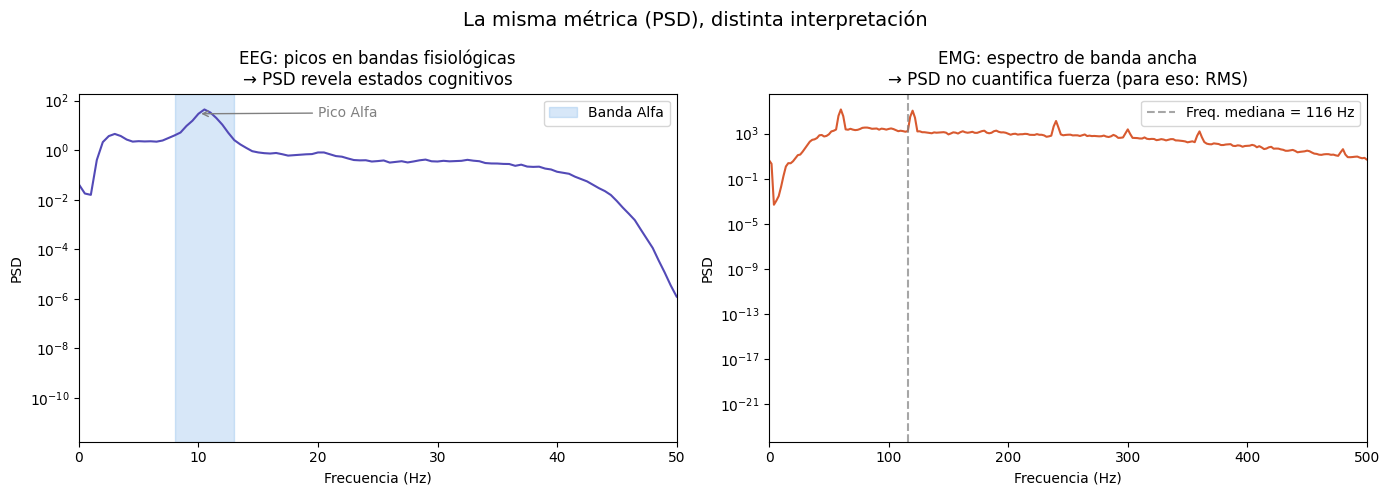


EEG → La PSD muestra DÓNDE está la potencia (bandas = estados cognitivos)
EMG → La PSD muestra el ANCHO DE BANDA (freq. mediana = 116 Hz)
      Para cuantificar FUERZA en EMG, usamos RMS, no PSD.


In [15]:
# Demostración: PSD de EEG vs PSD de EMG 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('La misma métrica (PSD), distinta interpretación', fontsize=14)

# PSD del EEG — usar canal_O1 (array 1D), no el DataFrame
f_eeg_demo, Pxx_eeg_demo = welch(canal_O1, fs=fm, nperseg=int(2*fm))
ax1.semilogy(f_eeg_demo, Pxx_eeg_demo, color='#534AB7', linewidth=1.5)
ax1.axvspan(8, 13, alpha=0.2, color='#378ADD', label='Banda Alfa')
ax1.set_xlabel('Frecuencia (Hz)')
ax1.set_ylabel('PSD')
ax1.set_title('EEG: picos en bandas fisiológicas\n→ PSD revela estados cognitivos')
ax1.set_xlim(0, 50)
ax1.legend()
ax1.annotate('Pico Alfa', xy=(10, Pxx_eeg_demo[np.argmin(np.abs(f_eeg_demo - 10))]),
             xytext=(20, Pxx_eeg_demo.max()*0.5),
             arrowprops=dict(arrowstyle='->', color='gray'),
             fontsize=10, color='gray')

# PSD del EMG
f_emg_demo, Pxx_emg_demo = welch(emg_filtered, fs=fs_emg, nperseg=int(0.5*fs_emg))
ax2.semilogy(f_emg_demo, Pxx_emg_demo, color='#D85A30', linewidth=1.5)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('PSD')
ax2.set_title('EMG: espectro de banda ancha\n→ PSD no cuantifica fuerza (para eso: RMS)')
ax2.set_xlim(0, min(500, fs_emg/2))

# Marcar frecuencia mediana (útil para fatiga)
potencia_acum = np.cumsum(Pxx_emg_demo)
f_mediana = f_emg_demo[np.argmin(np.abs(potencia_acum - potencia_acum[-1]/2))]
ax2.axvline(f_mediana, color='gray', linestyle='--', alpha=0.7,
            label=f'Freq. mediana = {f_mediana:.0f} Hz')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEEG → La PSD muestra DÓNDE está la potencia (bandas = estados cognitivos)")
print(f"EMG → La PSD muestra el ANCHO DE BANDA (freq. mediana = {f_mediana:.0f} Hz)")
print(f"      Para cuantificar FUERZA en EMG, usamos RMS, no PSD.")

## 6.9 Síntesis

La divergencia en las rutas de procesamiento no es arbitraria: refleja la física y la fisiología de cada señal. Como resumen:

1. El **EEG** es una señal oscilatoria generada por la sincronización de grandes poblaciones neuronales a través de un conductor de volumen complejo (cráneo + tejidos). Su información reside en las **frecuencias** de oscilación, por lo que la PSD y la potencia de banda son las métricas naturales (Nunez & Srinivasan, 2006; Cohen, 2014).

2. El **EMG** es una señal interferencial generada por la superposición estocástica de potenciales de acción de unidades motoras. Su información reside en la **amplitud** (cuántas unidades motoras se reclutan y a qué tasa disparan), por lo que el RMS y el iEMG son las métricas naturales (Merletti & Hermens, 2000; De Luca, 1997).

3. Aplicar la métrica equivocada a la señal equivocada (ej. rectificar EEG, o usar solo PSD para estimar fuerza en EMG) no produce errores de código, pero sí produce **interpretaciones fisiológicas erróneas** — que es un error más grave.

## 6.10 Ejercicios prácticos

Los siguientes ejercicios están diseñados para que estudiantes de licenciatura apliquen lo aprendido en este material. El objetivo no es únicamente ejecutar código en Python, sino comprender cómo las transformaciones digitales de la señal se relacionan con fenómenos fisiológicos reales.

Cada ejercicio incluye una breve explicación conceptual para que, al resolverlo, el estudiante sepa qué observar y cómo interpretar los resultados.

**Nota Importante:** Las siguientes celdas de código asumen que las celdas anteriores del notebook ya se han ejecutado. Específicamente, necesitamos que las siguientes variables estén definidas:

- `eeg_data`, `timeEEG`, `fm` (o `Fs`): Los datos de EEG cargados en la Sección 6.4.
- `waveData`, `timeEMG`, `fs_emg`: Los datos de EMG cargados en la Sección 6.4.
- `emg_filtered`: La señal EMG filtrada con paso banda (Sección 6.5).
- Las funciones de `scipy.signal`: `butter`, `filtfilt`.



### Ejercicio 6.1 Efecto del filtro Notch en una señal contaminada

**Contexto fisiológico:** La interferencia de la red eléctrica (60 Hz en México, 50 Hz en Europa) es uno de los artefactos más comunes en registros electrofisiológicos. En EEG, este ruido puede tener una amplitud comparable a la señal cerebral (~10-50 µV), mientras que en EMG, donde la señal es más grande, su efecto relativo es menor pero sigue presente. Cuando se usa un filtro paso banda que incluye los 60 Hz (como el rango EMG de 10–400 Hz), es necesario un filtro notch adicional para eliminar específicamente esa frecuencia sin afectar las frecuencias vecinas.

**Objetivo:** Implementar un filtro notch a 60 Hz y observar su efecto en el dominio de la frecuencia.

**Instrucciones:**

1. Tomar la señal EMG cruda (antes de cualquier filtrado).
2. Calcular y graficar la Densidad Espectral de Potencia (PSD) usando `scipy.signal.welch` para observar si hay un pico en 60 Hz.
3. Diseñar un filtro notch (band-stop) estrecho centrado en 60 Hz usando `scipy.signal.iirnotch`.
4. Aplicar el filtro notch a la señal cruda.
5. Calcular y graficar la PSD de la señal filtrada en el mismo plot.
6. Comparar ambas PSD y observar cómo desaparece (o se atenúa) el pico en 60 Hz sin afectar el resto del espectro.

**Pregunta para reflexionar:** ¿Por qué usamos un filtro notch en lugar de simplemente ajustar el filtro paso banda para que su frecuencia de corte superior sea menor a 60 Hz? ¿Qué información perderíamos en el caso del EMG?

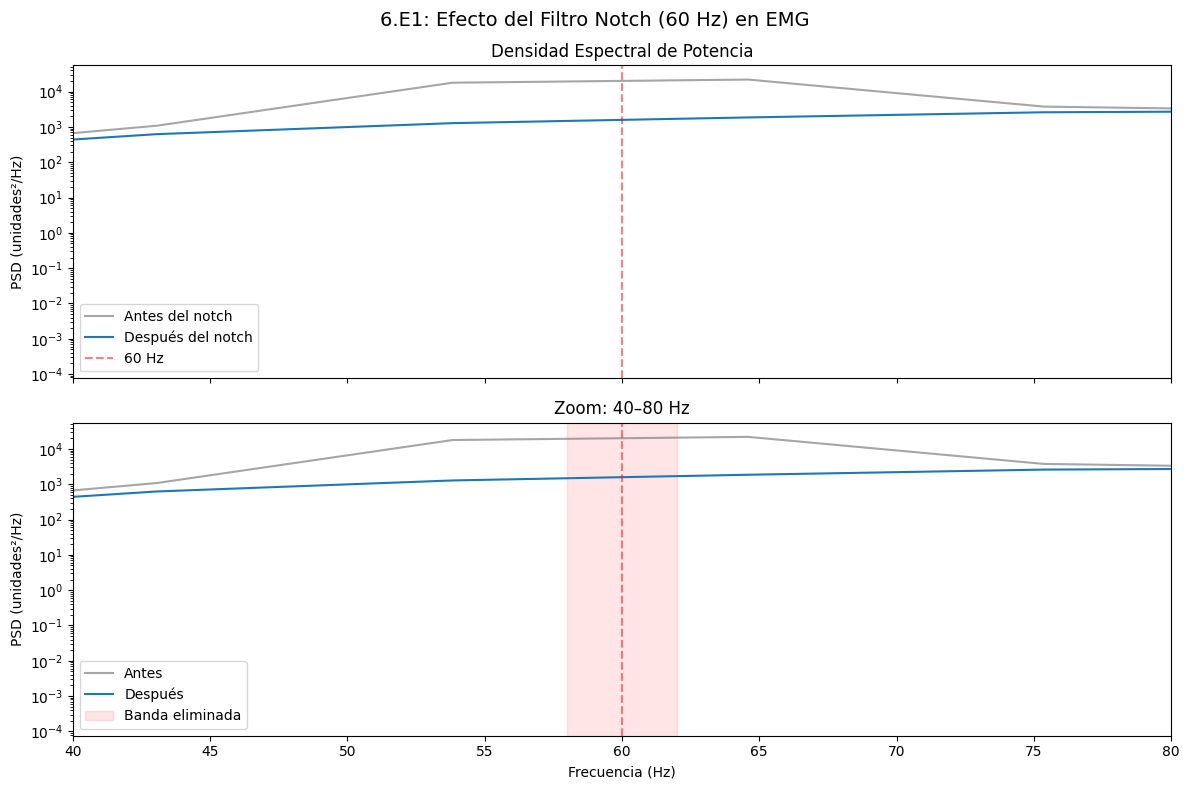


Filtro notch aplicado: f₀ = 60.0 Hz, Q = 30.0
Ancho de banda del notch ≈ 2.0 Hz


In [16]:
# 1. Parámetros del notch 
f_notch = 60.0       # Frecuencia a eliminar (Hz)
Q = 30.0             # Factor de calidad (ancho del notch: f_notch/Q ≈ 2 Hz)

# 2. PSD de la señal ANTES del notch 
# Usa la señal EMG cruda (emgData) y la frecuencia de muestreo (fs_meg)
f_psd_pre, Pxx_pre = welch(waveData, fs=fs_emg, nperseg=4096)

# 3. Diseñar y aplicar el filtro notch
b_notch, a_notch = iirnotch(f_notch, Q, fs=fs_emg)
emg_notched = filtfilt(b_notch, a_notch, waveData)

# 4. PSD de la señal DESPUÉS del notch
f_psd_post, Pxx_post = welch(emg_notched, fs=fs_emg, nperseg=4096)

# 5. Graficar comparación 
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
fig.suptitle('6.E1: Efecto del Filtro Notch (60 Hz) en EMG', fontsize=14)

# PSD completa
ax1.semilogy(f_psd_pre, Pxx_pre, color='gray', alpha=0.7, label='Antes del notch')
ax1.semilogy(f_psd_post, Pxx_post, color='tab:blue', label='Después del notch')
ax1.axvline(60, color='red', linestyle='--', alpha=0.5, label='60 Hz')
ax1.set_ylabel('PSD (unidades²/Hz)')
ax1.legend()
ax1.set_title('Densidad Espectral de Potencia')
ax1.set_xlim(0, min(500, fs_emg/2))

# Zoom alrededor de 60 Hz
ax2.semilogy(f_psd_pre, Pxx_pre, color='gray', alpha=0.7, label='Antes')
ax2.semilogy(f_psd_post, Pxx_post, color='tab:blue', label='Después')
ax2.axvline(60, color='red', linestyle='--', alpha=0.5)
ax2.axvspan(58, 62, color='red', alpha=0.1, label='Banda eliminada')
ax2.set_xlim(40, 80)
ax2.set_xlabel('Frecuencia (Hz)')
ax2.set_ylabel('PSD (unidades²/Hz)')
ax2.legend()
ax2.set_title('Zoom: 40–80 Hz')

plt.tight_layout()
plt.show()

print(f"\nFiltro notch aplicado: f₀ = {f_notch} Hz, Q = {Q}")
print(f"Ancho de banda del notch ≈ {f_notch/Q:.1f} Hz")

### Ejercicio 6.E2: ¿Qué pasa si se rectifica una señal de EEG?

**Contexto fisiológico:** En la Sección 6.6, explicamos que la rectificación es un paso fundamental del procesamiento de EMG, pero que **no se aplica al EEG**. La razón es que en el EEG, la fase positiva y negativa de las oscilaciones tiene significado fisiológico: representan la sincronización y desincronización de poblaciones neuronales. Rectificar el EEG destruye esta información oscilatoria.

Sin embargo, la mejor manera de entender *por qué* no se debe hacer algo es verlo con datos reales. En este ejercicio, aplicarás la misma cadena de procesamiento EMG (rectificación + envolvente) a una señal de EEG, y compararás el resultado con el análisis espectral que es el enfoque correcto para EEG.

**Objetivo:** Demostrar experimentalmente por qué la rectificación no es una operación adecuada para el EEG, comparando los resultados de ambos enfoques.

**Instrucciones:**

1. Tomar un segmento de señal EEG ya filtrada en la banda de interés (2–45 Hz).
2. **Ruta incorrecta (EMG sobre EEG):** Rectificar la señal EEG (valor absoluto) y calcular una envolvente RMS con ventana deslizante de 0.5 s. Graficar el resultado.
3. **Ruta correcta (Análisis espectral):** Calcular la PSD del mismo segmento usando `scipy.signal.welch`. Graficar la PSD e identificar las bandas de frecuencia (delta, theta, alfa, beta).
4. Crear una figura con 3 subplots: (a) EEG filtrado original, (b) EEG rectificado + envolvente RMS, (c) PSD del segmento.
5. Responder las preguntas de reflexión.

**Preguntas para reflexionar:**
- Al rectificar el EEG, ¿se puede distinguir entre un estado de ojos abiertos (supresión alfa) y ojos cerrados (potenciación alfa)?
- ¿Qué información oscilatoria se pierde al tomar el valor absoluto?
- ¿Por qué la envolvente RMS del EEG rectificado no aporta la misma información que el RMS del EMG?


Ejercicio 6.E2: Rectificar EEG — Por qué NO se debe hacer


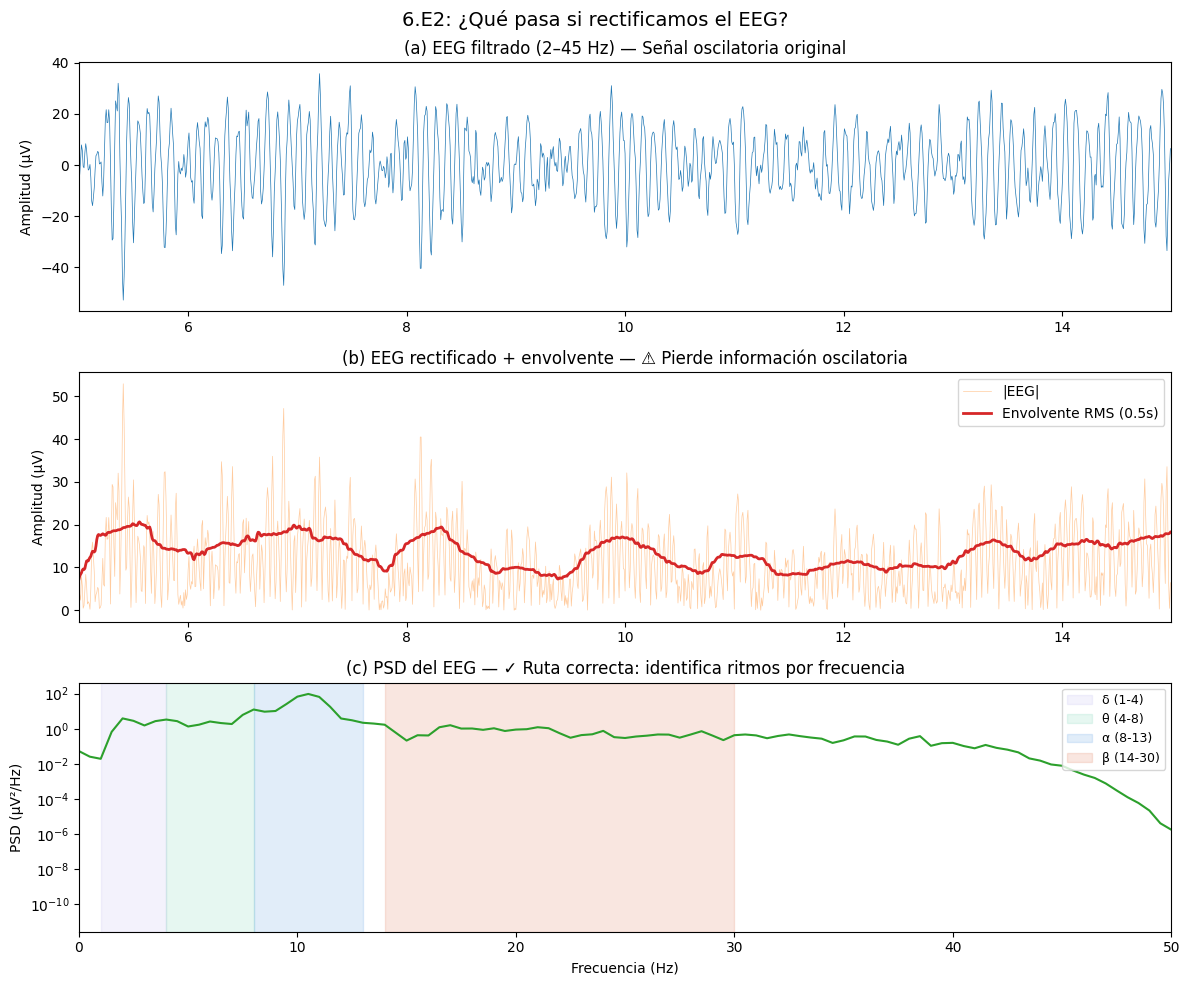


¿Qué observamos?
→ La rectificación (b) pierde TODA la información de frecuencia.
  Solo vemos 'cuánta actividad hay', pero no podemos distinguir alfa de beta.
→ La PSD (c) nos dice DÓNDE está la potencia: ¿domina alfa? ¿theta?
  Esta es la métrica relevante para estados cognitivos en EEG.


In [17]:
# Celda de Código: Ejercicio 6.E2
print("Ejercicio 6.E2: Rectificar EEG — Por qué NO se debe hacer")


# 0. Preparar señal EEG filtrada (canal O1, 2–45 Hz)
# Usar canal_O1 que ya definimos (array 1D del DataFrame eeg_filtered)
# Si no existe, crearlo:
# canal_O1 = eeg_filtered.iloc[:, 6].to_numpy()

# Crear vector de tiempo
timeEEG = np.arange(len(canal_O1)) / fm

# Seleccionar segmento de 10 segundos
t_inicio = 5   # segundos
t_fin = 15     # segundos
mask_eeg = (timeEEG >= t_inicio) & (timeEEG < t_fin)
seg_eeg = canal_O1[mask_eeg]
seg_time = timeEEG[mask_eeg]

# 1. RUTA "INCORRECTA": Rectificación + Envolvente RMS 
eeg_rect = np.abs(seg_eeg)

# RMS con ventana deslizante de 0.5 s
ventana_rms = int(0.5 * fm)  # muestras en 0.5 s
eeg_rms = np.array([
    np.sqrt(np.mean(eeg_rect[max(0,i-ventana_rms//2):i+ventana_rms//2]**2))
    for i in range(len(eeg_rect))
])

# 2. RUTA CORRECTA: Análisis espectral (PSD) 
f_psd, Pxx_eeg = welch(seg_eeg, fs=fm, nperseg=int(2*fm))  # ventana de 2s

#  3. Graficar comparación 
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('6.E2: ¿Qué pasa si rectificamos el EEG?', fontsize=14)

# (a) EEG filtrado original
axes[0].plot(seg_time, seg_eeg, color='tab:blue', linewidth=0.5)
axes[0].set_ylabel('Amplitud (µV)')
axes[0].set_title('(a) EEG filtrado (2–45 Hz) — Señal oscilatoria original')
axes[0].set_xlim(t_inicio, t_fin)

# (b) EEG rectificado + envolvente (INCORRECTO para EEG)
axes[1].plot(seg_time, eeg_rect, color='tab:orange', alpha=0.4, linewidth=0.5, label='|EEG|')
axes[1].plot(seg_time, eeg_rms, color='tab:red', linewidth=2, label='Envolvente RMS (0.5s)')
axes[1].set_ylabel('Amplitud (µV)')
axes[1].set_title('(b) EEG rectificado + envolvente — ⚠️ Pierde información oscilatoria')
axes[1].legend()
axes[1].set_xlim(t_inicio, t_fin)

# (c) PSD  Ruta correcta
axes[2].semilogy(f_psd, Pxx_eeg, color='tab:green', linewidth=1.5)
bandas = {'δ (1-4)': (1,4), 'θ (4-8)': (4,8), 'α (8-13)': (8,13), 'β (14-30)': (14,30)}
colores_banda = ['#AFA9EC', '#5DCAA5', '#378ADD', '#D85A30']
for (nombre, (fl, fh)), c in zip(bandas.items(), colores_banda):
    axes[2].axvspan(fl, fh, alpha=0.15, color=c, label=nombre)
axes[2].set_xlabel('Frecuencia (Hz)')
axes[2].set_ylabel('PSD (µV²/Hz)')
axes[2].set_title('(c) PSD del EEG — ✓ Ruta correcta: identifica ritmos por frecuencia')
axes[2].legend(loc='upper right', fontsize=9)
axes[2].set_xlim(0, 50)

plt.tight_layout()
plt.show()

print("\n¿Qué observamos?")
print("→ La rectificación (b) pierde TODA la información de frecuencia.")
print("  Solo vemos 'cuánta actividad hay', pero no podemos distinguir alfa de beta.")
print("→ La PSD (c) nos dice DÓNDE está la potencia: ¿domina alfa? ¿theta?")
print("  Esta es la métrica relevante para estados cognitivos en EEG.")


**Referencias Bibliográficas**
* Basmajian, J. V., & De Luca, C. J. (1985). *Muscles alive: Their functions revealed by electromyography* (5th ed.). Williams & Wilkins.
* Cohen, M. X. (2014). *Analyzing neural time series data: theory and practice*. MIT Press.
* De Luca, C. J. (1997). The use of surface electromyography in biomechanics. *Journal of Applied Biomechanics*, 13(2), 135–163.
* McKiernan, E. C. (2025). *Open teaching materials for biomedical signal analysis*. https://emckiernan.curve.space/ 
* Merletti, R., & Hermens, H. J. (2000). Detection and conditioning of surface EMG signals: State of the art. *Journal of Electromyography and Kinesiology*, 10(6), 387–404.
* Mogk, J. P. M., & Keir, P. J. (2003). Crosstalk in surface electromyography of the upper extremity. Journal of Electromyography and Kinesiology, 13(1), 63–72.
* Nunez, P. L., & Srinivasan, R. (2006). *Electric fields of the brain: The neurophysics of EEG*. Oxford University Press.
* Ozdemir, M. A., Kisa, D. H., Guren, O., & Akan, A. (2022). Dataset for multi-channel surface electromyography (sEMG) signals of hand gestures. *Data in Brief*, 41, 107921.
* Rubio García, A. (2024). Electromiograma de músculos del antebrazo a distintas fuerzas. Proyecto Final, Electrofisiología. Facultad de Ciencias, UNAM.
* Shankar, S., Murphy, B. B., Driscoll, N., Shekhirev, M., Valurouthu, G., Shevchuk, K., ... & Vitale, F. (2023). Effect of the deposition process on the stability of Ti3C2T x MXene films for bioelectronics. 2D Materials, 10(4), 044001.
* Widmann, A., Schröger, E., & Maess, B. (2015). Digital filter design for electrophysiological data – A practical approach. *Journal of Neuroscience Methods*, 250, 34–46.